# Airport Security Wait Time - Exploratory Data Analysis

This notebook walks through the data, runs SQL queries, and visualises patterns
in the airport security wait time dataset.

**Run the pipeline scripts first:**
```
python scripts/generate_sample_data.py
python scripts/import_data.py
python scripts/clean_data.py
```

In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Path to database (works when notebook is run from the notebooks/ folder)
DB_PATH = os.path.join('..', 'database', 'airport_waits.db')
conn = sqlite3.connect(DB_PATH)
print('Connected to:', os.path.abspath(DB_PATH))

Connected to: C:\Users\aliel\Desktop\Airport_analytics\database\airport_waits.db


## 1. Preview the Tables

In [2]:
tables = ['cleaned_flights', 'cleaned_weather',
          'cleaned_passenger_traffic', 'cleaned_security_wait_times']

for t in tables:
    df = pd.read_sql_query(f'SELECT * FROM {t} LIMIT 3', conn)
    print(f'\n-- {t} --')
    display(df)


-- cleaned_flights --


,flight_id,date,airline,terminal,scheduled_departure,delay_minutes,flight_status
0,1,2024-01-01,Delta,B,19:30,22,Delayed
1,2,2024-01-01,American,C,15:30,30,Delayed
2,3,2024-01-01,United,B,06:45,26,Delayed



-- cleaned_weather --


,date,condition,temperature_f,wind_speed_mph,visibility_miles
0,2024-01-01,Cloudy,65.3,4.9,6.5
1,2024-01-02,Rain,35.9,13.3,7.9
2,2024-01-03,Clear,45.4,9.6,7.9



-- cleaned_passenger_traffic --


,id,date,terminal,hour,passenger_count
0,1,2024-01-01,A,6,151
1,2,2024-01-01,A,7,399
2,3,2024-01-01,A,8,428



-- cleaned_security_wait_times --


,id,date,terminal,hour,wait_time_minutes
0,1,2024-01-01,A,6,11.0
1,2,2024-01-01,A,7,50.9
2,3,2024-01-01,A,8,39.2


## 2. Wait Time Distribution

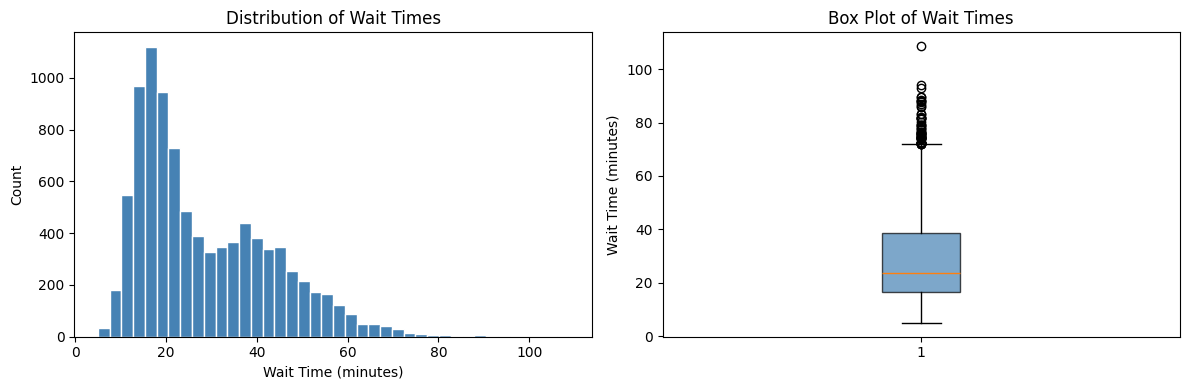

count    9180.00
mean       28.44
std        14.72
min         5.00
25%        16.60
50%        23.50
75%        38.70
max       108.60
Name: wait_time_minutes, dtype: float64


In [3]:
wait_df = pd.read_sql_query(
    'SELECT wait_time_minutes FROM cleaned_security_wait_times', conn
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(wait_df['wait_time_minutes'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Wait Times')
axes[0].set_xlabel('Wait Time (minutes)')
axes[0].set_ylabel('Count')

axes[1].boxplot(wait_df['wait_time_minutes'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Box Plot of Wait Times')
axes[1].set_ylabel('Wait Time (minutes)')

plt.tight_layout()
plt.show()

print(wait_df['wait_time_minutes'].describe().round(2))

## 3. Average Wait Time by Hour

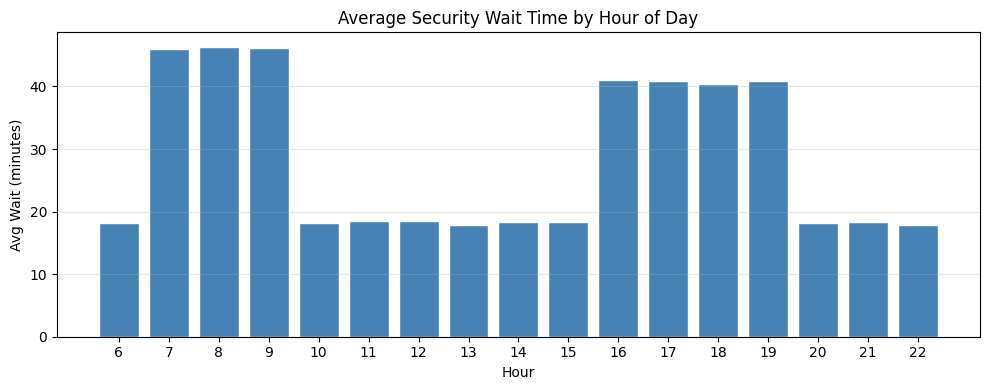

In [4]:
hourly = pd.read_sql_query("""
    SELECT hour, ROUND(AVG(wait_time_minutes), 2) AS avg_wait
    FROM cleaned_security_wait_times
    GROUP BY hour
    ORDER BY hour
""", conn)

plt.figure(figsize=(10, 4))
plt.bar(hourly['hour'], hourly['avg_wait'], color='steelblue', edgecolor='white')
plt.title('Average Security Wait Time by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Wait (minutes)')
plt.xticks(hourly['hour'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Wait Time by Terminal

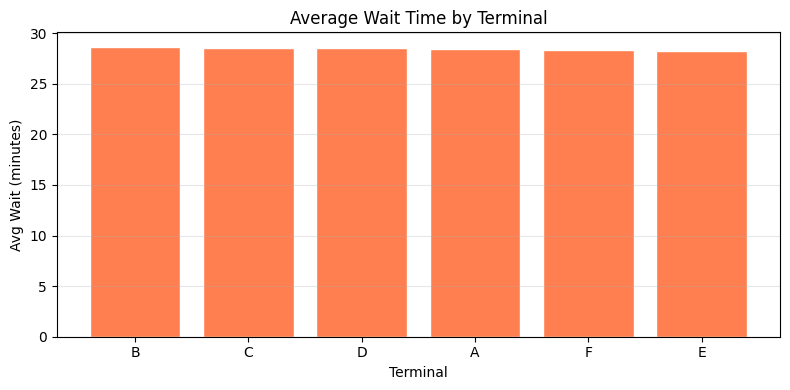

,terminal,avg_wait,min_wait,max_wait
0,B,28.64,5.0,108.6
1,C,28.57,5.7,89.7
2,D,28.51,7.5,86.9
3,A,28.41,6.1,89.4
4,F,28.32,5.0,92.9
5,E,28.21,5.0,88.5


In [5]:
terminal_df = pd.read_sql_query("""
    SELECT terminal,
           ROUND(AVG(wait_time_minutes), 2) AS avg_wait,
           ROUND(MIN(wait_time_minutes), 2) AS min_wait,
           ROUND(MAX(wait_time_minutes), 2) AS max_wait
    FROM cleaned_security_wait_times
    GROUP BY terminal
    ORDER BY avg_wait DESC
""", conn)

plt.figure(figsize=(8, 4))
plt.bar(terminal_df['terminal'], terminal_df['avg_wait'],
        color='coral', edgecolor='white')
plt.title('Average Wait Time by Terminal')
plt.xlabel('Terminal')
plt.ylabel('Avg Wait (minutes)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(terminal_df)

## 5. Weather Condition vs Wait Time

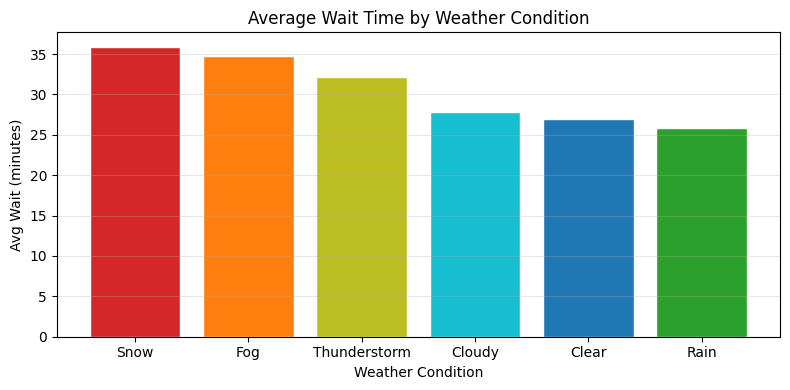

,condition,avg_wait
0,Snow,35.89
1,Fog,34.70
2,Thunderstorm,32.14
3,Cloudy,27.83
4,Clear,26.98
5,Rain,25.80


In [6]:
weather_wait = pd.read_sql_query("""
    SELECT w.condition,
           ROUND(AVG(s.wait_time_minutes), 2) AS avg_wait
    FROM cleaned_security_wait_times s
    JOIN cleaned_weather w ON s.date = w.date
    GROUP BY w.condition
    ORDER BY avg_wait DESC
""", conn)

colors = ['#d62728', '#ff7f0e', '#bcbd22', '#17becf', '#1f77b4', '#2ca02c']
plt.figure(figsize=(8, 4))
plt.bar(weather_wait['condition'], weather_wait['avg_wait'],
        color=colors[:len(weather_wait)], edgecolor='white')
plt.title('Average Wait Time by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Avg Wait (minutes)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(weather_wait)

## 6. Passenger Count vs Wait Time (Scatter)

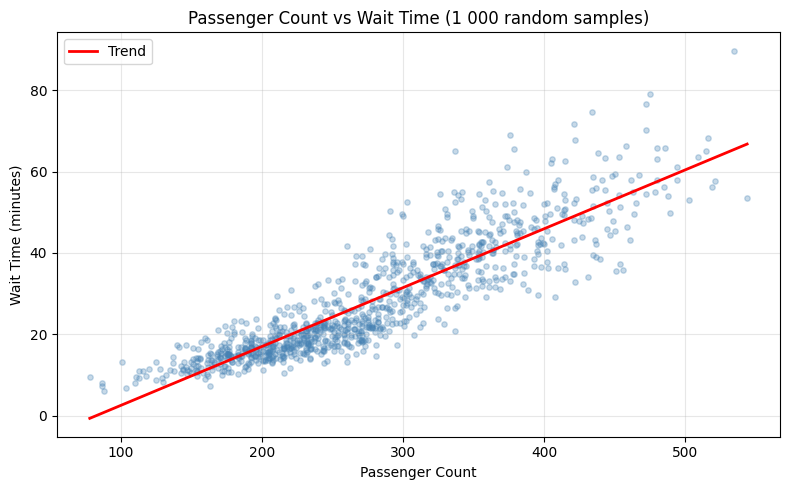

In [7]:
scatter_df = pd.read_sql_query("""
    SELECT p.passenger_count, s.wait_time_minutes
    FROM cleaned_passenger_traffic p
    JOIN cleaned_security_wait_times s
      ON p.date = s.date AND p.terminal = s.terminal AND p.hour = s.hour
    ORDER BY RANDOM()
    LIMIT 1000
""", conn)

plt.figure(figsize=(8, 5))
plt.scatter(scatter_df['passenger_count'], scatter_df['wait_time_minutes'],
            alpha=0.3, s=15, color='steelblue')

z = np.polyfit(scatter_df['passenger_count'], scatter_df['wait_time_minutes'], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_df['passenger_count'].min(),
                     scatter_df['passenger_count'].max(), 100)
plt.plot(x_line, p(x_line), 'r-', linewidth=2, label='Trend')

plt.title('Passenger Count vs Wait Time (1 000 random samples)')
plt.xlabel('Passenger Count')
plt.ylabel('Wait Time (minutes)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Airline Delay Summary

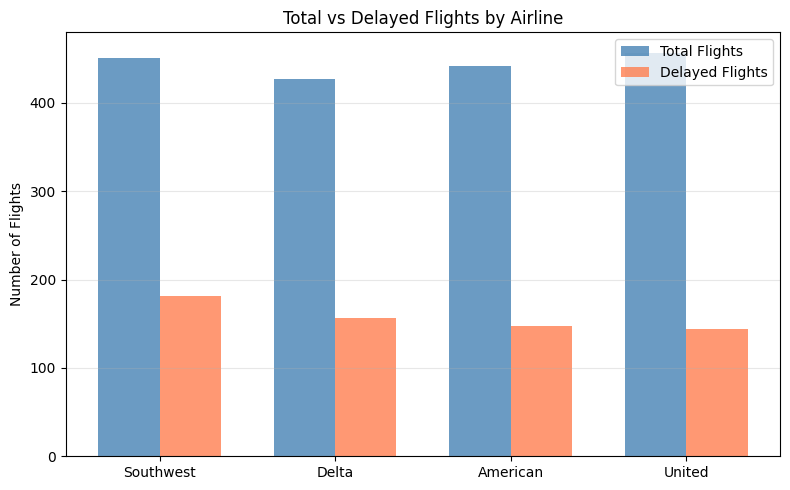

,airline,total_flights,delayed,avg_delay_min
0,Southwest,451,181,15.7
1,Delta,427,156,14.6
2,American,442,147,14.6
3,United,457,144,14.0


In [8]:
airline_df = pd.read_sql_query("""
    SELECT airline,
           COUNT(*) AS total_flights,
           SUM(CASE WHEN flight_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
           ROUND(AVG(delay_minutes), 1) AS avg_delay_min
    FROM cleaned_flights
    GROUP BY airline
    ORDER BY avg_delay_min DESC
""", conn)

x = np.arange(len(airline_df))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(x - width/2, airline_df['total_flights'], width,
        label='Total Flights', color='steelblue', alpha=0.8)
ax1.bar(x + width/2, airline_df['delayed'], width,
        label='Delayed Flights', color='coral', alpha=0.8)

ax1.set_xticks(x)
ax1.set_xticklabels(airline_df['airline'])
ax1.set_ylabel('Number of Flights')
ax1.set_title('Total vs Delayed Flights by Airline')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(airline_df)

In [9]:
conn.close()
print('Done. Database connection closed.')

Done. Database connection closed.
